In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

import statsmodels.api as sm

from ISLP.models import ModelSpec as MS
from ISLP.models import poly
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import mean_squared_error


# Model Validation

## Variation in Predictions
Train from a single data set, once for:
$$
y = 2 - 1.5 X_1 + \epsilon
$$
Test main times and check MSE, and see the variation with testing sets.

In [8]:
# reset seed
np.random.seed(100)

# number of samples
n = 50
# create x values
x = np.random.uniform(0, 15, size=n)
# set true coefficients
beta0_true = 2.0
beta1_true = -1.5
# set noise parameters
eps = 1.0
y = beta0_true + beta1_true * x + eps * np.random.normal(size=n)

train_df = pd.DataFrame({"x": x, "y": y})

# fit the linear model

design = MS(['x'])
X_train = design.fit_transform(train_df)

# X_train = sm.add_constant(train_df["x"])
lm_fit = sm.OLS(train_df["y"], X_train).fit()

# testing error
n_tests = 1000 # iid testing sets
mse = np.empty(n_tests) # 1000 estimates of MSE

m = 50 # number of test samples per test set

for j in range(n_tests):
    x = np.random.uniform(0, 15, size=m)
    y = beta0_true + beta1_true * x + eps * np.random.normal(size=m)
    test_df = pd.DataFrame({"x": x, "y": y})
    X_test = design.transform(test_df)
    # compute preidction on testing data
    preds = lm_fit.predict(X_test)
    # compute the error
    mse[j] = mean_squared_error(test_df["y"], preds)


Text(0, 0.5, 'Frequency')

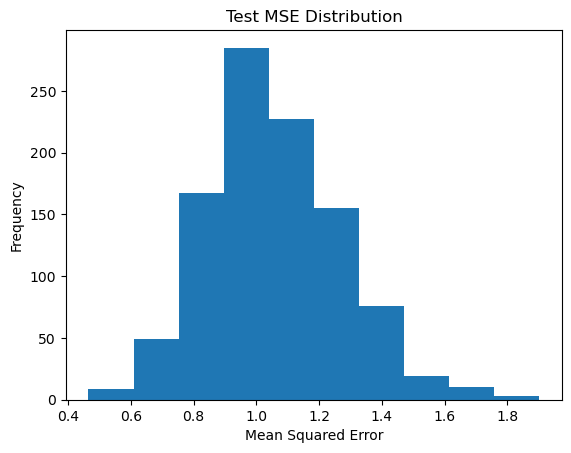

In [9]:
fig, axes = plt.subplots()
axes.hist(mse, bins=10)
axes.set_title("Test MSE Distribution")
axes.set_xlabel("Mean Squared Error")
axes.set_ylabel("Frequency")

# Bias Variance Tradeoff
Try fitting data generated from
$$
Y = e^X(1 + \xi), \quad \xi \sim N(0,0.25)
$$
with polynomials of different degree.  Then evaluate how training and testing error varies as we try different degree polynomials.

**NOTE** Strictly speaking, this is not of the form
$$
Y = f(X) + \epsilon
$$
We break assumption to get a more exaggerated effect.  But everything we have done assumed *additive* noise.

## Model Comparison

In [10]:
np.random.seed(100)

# test/train sample size
n = 10**2
# number of independent runs
m = 10**2

maxp = 10

# preallocate arrays
test_MSE_vals = np.zeros(maxp)
train_MSE_vals = np.zeros(maxp)

# generate training data
x_train = np.random.uniform(0, 5, n)
y_train = np.exp(x_train) * (1 + 0.5 * np.random.randn(n))
train_df = pd.DataFrame({"x": x_train, "y": y_train})

# loop over independent test sets
for j in range(m):

    # generate testing data
    x_test = np.random.uniform(0, 5, n)
    y_test = np.exp(x_test) * (1 + 0.5 * np.random.randn(n))
    test_df = pd.DataFrame({"x": x_test, "y": y_test})

    # try polynomial fits
    for p in range(1, maxp + 1):

        # create model specification using orthogonal polynomials
        design = MS([poly("x", degree=p)])
        
        X_train = design.fit_transform(train_df)
        X_test = design.transform(test_df)

        # fit model
        model = sm.OLS(train_df["y"], X_train).fit()

        # training MSE
        train_MSE_vals[p-1] += np.mean(model.resid**2) / m

        # testing MSE
        y_pred_test = model.predict(X_test)
        test_MSE_vals[p-1] +=mean_squared_error(test_df["y"], y_pred_test) / m




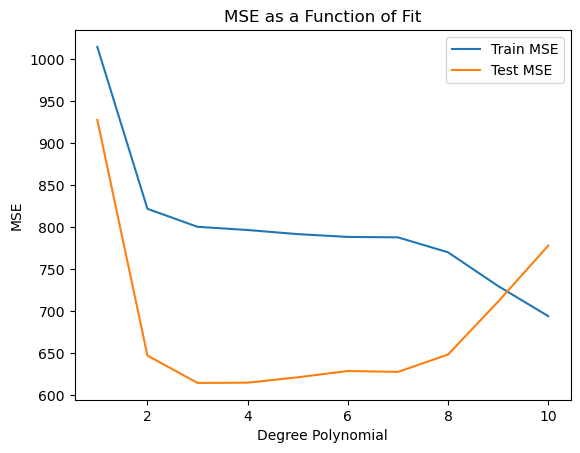

In [11]:
fig, ax = plt.subplots()
ax.plot(range(1, maxp + 1), train_MSE_vals, label="Train MSE")
ax.plot(range(1, maxp + 1), test_MSE_vals, label="Test MSE")
ax.set_xlabel("Degree Polynomial")
ax.set_ylabel("MSE")
ax.set_title("MSE as a Function of Fit")
ax.legend()


Typical response pattern:
* Training MSE continues to fall as we increase model complexity (degree of the polynomial here)
* Testing MSE has a U shape

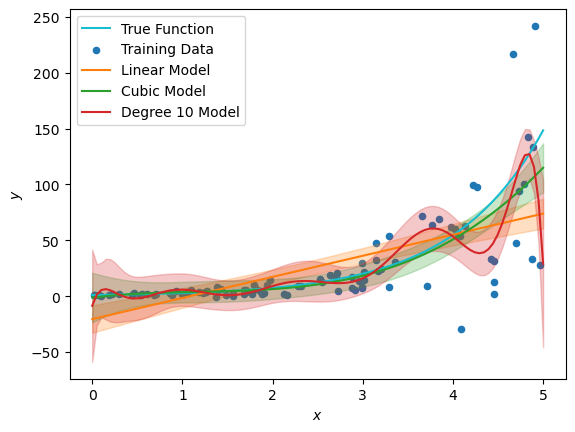

In [ ]:
design1 = MS([poly("x", degree=1)])
X_train1 = design1.fit_transform(train_df)
model1 = sm.OLS(train_df["y"], X_train1).fit()

design3 = MS([poly("x", degree=3)])
X_train3 = design3.fit_transform(train_df)
model3 = sm.OLS(train_df["y"], X_train3).fit()


design10 = MS([poly("x", degree=10)])
X_train10 = design10.fit_transform(train_df)
model10 = sm.OLS(train_df["y"], X_train10).fit()


fig, ax = plt.subplots()

xx = np.linspace(0, 5, 100)
ax.plot(xx, np.exp(xx), label="True Function", color='C9')
train_df.plot.scatter(x="x", y="y", ax=ax, label="Training Data")
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

x_vals = np.linspace(0,5, 100)

X_pred1 = design1.transform(pd.DataFrame({"x": x_vals}))
y_pred1 = model1.get_prediction(X_pred1)
y_pred1_ci = y_pred1.conf_int()
ax.plot(x_vals, y_pred1.predicted_mean, label="Linear Model", color='C1',)
ax.fill_between(
    x_vals,
    y_pred1_ci[:,0], # lower bound
    y_pred1_ci[:,1], # upper bound
    color='C1',
    alpha=0.25,     # transparency
    label='',
)


X_pred3 = design3.transform(pd.DataFrame({"x": x_vals}))
y_pred3 = model3.get_prediction(X_pred3)
y_pred3_ci = y_pred3.conf_int()
ax.plot(x_vals, y_pred3.predicted_mean, label="Cubic Model", color='C2',)
ax.fill_between(
    x_vals,
    y_pred3_ci[:,0], # lower bound
    y_pred3_ci[:,1], # upper bound
    color='C2',
    alpha=0.25,     # transparency
    label='',
)


X_pred10 = design10.transform(pd.DataFrame({"x": x_vals}))
y_pred10 = model10.get_prediction(X_pred10)
y_pred10_ci = y_pred10.conf_int()
ax.plot(x_vals, y_pred10.predicted_mean, label="Degree 10 Model", color='C3',)
ax.fill_between(
    x_vals,
    y_pred10_ci[:,0], # lower bound
    y_pred10_ci[:,1], # upper bound
    color='C3',
    alpha=0.25,     # transparency
    label='',
)
ax.legend()



## Impact of Training Set Size
Larger training data set sizes tends to reduce error

In [ ]:
np.random.seed(100)

# Training set size values
n_train = np.array([5, 10, 20, 40, 80])

# Validation (testing) set is fixed
n_test = 10**4

# Set true coefficients
beta0_true = 2.0
beta1_true = -1.5
eps = 1.0

# Construct validation set, fixed over the entire computation
x_test = np.random.uniform(0, 15, n_test)
y_test = beta0_true + beta1_true * x_test + eps * np.random.normal(size=n_test)
test_df = pd.DataFrame({"x": x_test, "y": y_test})

# Number of samples per training set size
n_samples = 100

# Lists to store results
mse_vals = []
n_vals = []

design = MS(["x"])

# Loop over each training set size, n_samples times
for n in n_train:
    for i in range(n_samples):
        x = np.random.uniform(0, 15, n)
        y = beta0_true + beta1_true * x + eps * np.random.normal(size=n)
        train_df = pd.DataFrame({"x": x, "y": y})
        X_train = design.fit_transform(train_df)
        # Fit linear model
        model = sm.OLS(train_df["y"], X_train).fit()
        
        # Predict on test set and compute MSE
        X_test = design.transform(test_df)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(test_df["y"], y_pred)  # Alternatively: mse =
                
        # Record n and MSE
        n_vals.append(n)
        mse_vals.append(mse)

# Convert to DataFrame
mse_df = pd.DataFrame({"n": n_vals, "MSE": mse_vals})
mse_df['n'] = mse_df['n'].astype('category')

# Create boxplot
fig, ax = plt.subplots()
mse_df.boxplot(column="MSE", by="n", ax=ax)
ax.set_yscale("log")
ax.set_title(f"Mean Squared Error of a Linear Model\n{n_samples} Training Sets of Size {n_test}")
ax.set_xlabel("Training Set Size")
ax.set_ylabel("MSE")
fig.suptitle("")  # Remove default title


## Variability from Training/Testing Splits

In [ ]:
np.random.seed(100)

# test/train sample size
n = 10**3
# number of splits
m = 5
maxp = 25

# storage
test_mse_vals = []
trial_vals = []
p_vals = []

# generate full dataset
x = np.random.uniform(0, 5, size=n)
y = np.exp(x) * (1 + 0.5 * np.random.randn(n))
data_df = pd.DataFrame({"x": x, "y": y})

# repeated 50/50 train-test splits
for j in range(1, m + 1):
    idx_train = np.random.choice(n, size=n // 2, replace=False)
    train_df = data_df.iloc[idx_train]
    test_df = data_df.drop(data_df.index[idx_train])

    for p in range(1, maxp + 1):
        design = MS([poly("x", degree=p)])
        X_train = design.fit_transform(train_df)
        X_test = design.transform(test_df)

        lm_fit = sm.OLS(train_df["y"], X_train).fit()
        y_pred = lm_fit.predict(X_test)

        test_mse_vals.append(mean_squared_error(test_df["y"], y_pred))
        p_vals.append(p)
        trial_vals.append(j)

mse_df = pd.DataFrame({"p": p_vals, "MSE": test_mse_vals, "Trial": trial_vals})
mse_df["p"] = mse_df["p"].astype(int)
mse_df["Trial"] = mse_df["Trial"].astype("category")

fig, ax = plt.subplots()
for trial, g in mse_df.groupby("Trial"):
    ax.plot(g["p"], g["MSE"], linewidth=2, label=f"Trial {trial}")

ax.set_xlabel("Degree of Polynomial")
ax.set_ylabel("MSE")
ax.set_title("50% Train-Test Data Split")
ax.set_yscale("log")
ax.legend()

# LOOCV

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_validate, KFold


In [ ]:
np.random.seed(100)

# test/train sample size
n = 10**2
maxp = 10

# generate full dataset
x = np.random.uniform(0, 5, size=n)
y = np.exp(x) * (1 + 0.5 * np.random.randn(n))
data_df = pd.DataFrame({"x": x, "y": y})


In [ ]:
# fit and estimate LOOCV MSE
cv_test_vals = []
cv_train_vals = []
for p in range(1, maxp+1):
    # turn intercept off since LinearRegression will handle it
    design = MS([poly("x", degree=p)],intercept=False)
    X = design.fit_transform(data_df)

    model = LinearRegression()
    # by default, it does not retain the training data
    cv_results = cross_validate(model, X, data_df["y"], cv=LeaveOneOut(), scoring='neg_mean_squared_error', return_train_score=True)
    cv_train_vals.append(-cv_results['train_score'].mean())
    cv_test_vals.append(-cv_results['test_score'].mean())


In [ ]:
fig, ax = plt.subplots()
ax.scatter(np.arange(1, maxp+1), cv_train_vals,label='Training')
ax.scatter(np.arange(1, maxp+1), cv_test_vals,label='Testing')
ax.set_xlabel('Polynomial Degree $p$')
ax.set_ylabel('LOOCV MSE')
ax.legend()


In [ ]:
## K-fold CV

In [ ]:
# fit and estimate LOOCV MSE
cv_test_vals = []
cv_train_vals = []

cv = KFold(n_splits=5, shuffle=True, random_state=100)

for p in range(1, maxp+1):
    # turn intercept off since LinearRegression will handle it
    design = MS([poly("x", degree=p)],intercept=False)
    X = design.fit_transform(data_df)

    model = LinearRegression()
    # by default, it does not retain the training data
    cv_results = cross_validate(model, X, data_df["y"], cv=cv, scoring='neg_mean_squared_error', return_train_score=True)
    cv_train_vals.append(-cv_results['train_score'].mean())
    cv_test_vals.append(-cv_results['test_score'].mean())


In [ ]:
fig, ax = plt.subplots()
ax.scatter(np.arange(1, maxp+1), cv_train_vals,label='Training')
ax.scatter(np.arange(1, maxp+1), cv_test_vals,label='Testing')
ax.set_xlabel('Polynomial Degree $p$')
ax.set_ylabel('LOOCV MSE')
ax.legend()
